In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported!")

All libraries imported!


In [24]:
# Using a reliable dataset from Kaggle's seaborn built-in data
# This is a well-known housing dataset that always works!
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Rename columns to be more readable
df = df.rename(columns={
    'medv'  : 'price',       # House price (target column)
    'rm'    : 'avg_rooms',   # Average number of rooms
    'age'   : 'house_age',   # Age of house
    'dis'   : 'distance',    # Distance to employment centres
    'tax'   : 'tax_rate',    # Tax rate
    'lstat' : 'low_income_pct', # % lower income population
    'crim'  : 'crime_rate',  # Crime rate
    'nox'   : 'air_pollution', # Air pollution level
    'ptratio': 'school_ratio', # Pupil-teacher ratio
    'indus' : 'industry_pct',  # % industrial area
    'zn'    : 'residential_pct', # % residential zone
    'chas'  : 'near_river',   # Near river (1=yes, 0=no)
    'rad'   : 'highway_access', # Highway access index
    'b'     : 'diversity_index' # Diversity index
})

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded successfully!
Rows: 506, Columns: 14


,crime_rate,residential_pct,industry_pct,near_river,air_pollution,avg_rooms,house_age,distance,highway_access,tax_rate,school_ratio,diversity_index,low_income_pct,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [7]:
print("=== COLUMN NAMES ===")
print(list(df.columns))

print("\n=== DATA TYPES & MISSING VALUES ===")
df.info()

=== COLUMN NAMES ===
['crime_rate', 'residential_pct', 'industry_pct', 'near_river', 'air_pollution', 'avg_rooms', 'house_age', 'distance', 'highway_access', 'tax_rate', 'school_ratio', 'diversity_index', 'low_income_pct', 'price']

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   crime_rate       506 non-null    float64
 1   residential_pct  506 non-null    float64
 2   industry_pct     506 non-null    float64
 3   near_river       506 non-null    int64  
 4   air_pollution    506 non-null    float64
 5   avg_rooms        506 non-null    float64
 6   house_age        506 non-null    float64
 7   distance         506 non-null    float64
 8   highway_access   506 non-null    int64  
 9   tax_rate         506 non-null    int64  
 10  school_ratio     506 non-null    float64
 11  diversity_index  506 no

In [8]:
print("=== PRICE STATISTICS ===")
print(f"Lowest  price : ${df['price'].min()}k")
print(f"Highest price : ${df['price'].max()}k")
print(f"Average price : ${df['price'].mean():.2f}k")
print(f"Median  price : ${df['price'].median()}k")

print("\n=== FULL STATS ===")
df.describe().round(2)

=== PRICE STATISTICS ===
Lowest  price : $5.0k
Highest price : $50.0k
Average price : $22.53k
Median  price : $21.2k

=== FULL STATS ===


,crime_rate,residential_pct,industry_pct,near_river,air_pollution,avg_rooms,house_age,distance,highway_access,tax_rate,school_ratio,diversity_index,low_income_pct,price
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


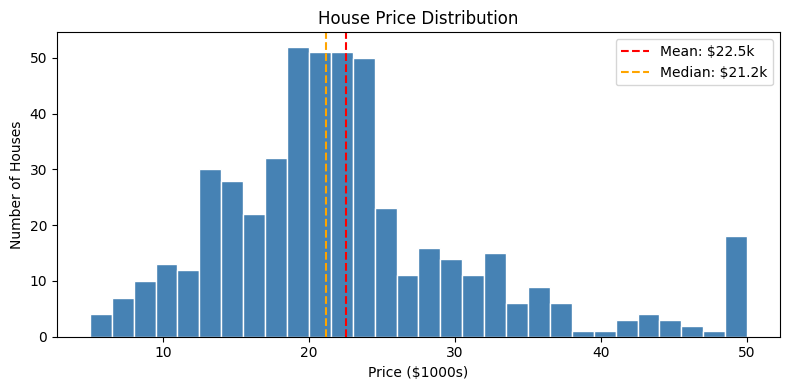

In [9]:
# How are house prices spread?
plt.figure(figsize=(8, 4))
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['price'].mean(),   color='red',    linestyle='--', label=f"Mean: ${df['price'].mean():.1f}k")
plt.axvline(df['price'].median(), color='orange', linestyle='--', label=f"Median: ${df['price'].median()}k")
plt.title('House Price Distribution')
plt.xlabel('Price ($1000s)')
plt.ylabel('Number of Houses')
plt.legend()
plt.tight_layout()
plt.show()

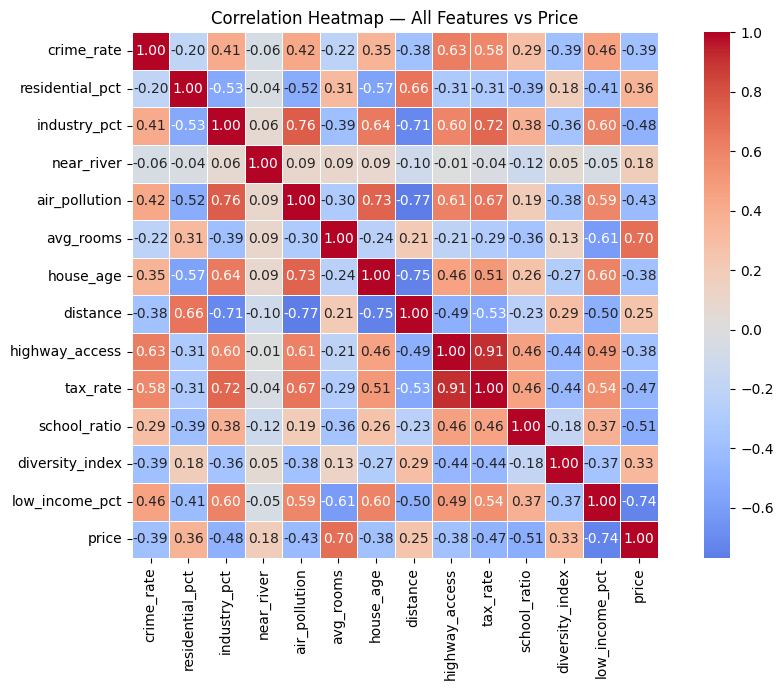


Top features correlated with PRICE:
low_income_pct    -0.738
school_ratio      -0.508
industry_pct      -0.484
tax_rate          -0.469
air_pollution     -0.427
crime_rate        -0.388
highway_access    -0.382
house_age         -0.377
near_river         0.175
distance           0.250
diversity_index    0.333
residential_pct    0.360
avg_rooms          0.695
price              1.000
Name: price, dtype: float64


In [10]:
# Correlation shows how strongly each feature is related to price
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — All Features vs Price')
plt.tight_layout()
plt.show()

# Print top correlations with price specifically
print("\nTop features correlated with PRICE:")
print(corr['price'].sort_values().round(3))

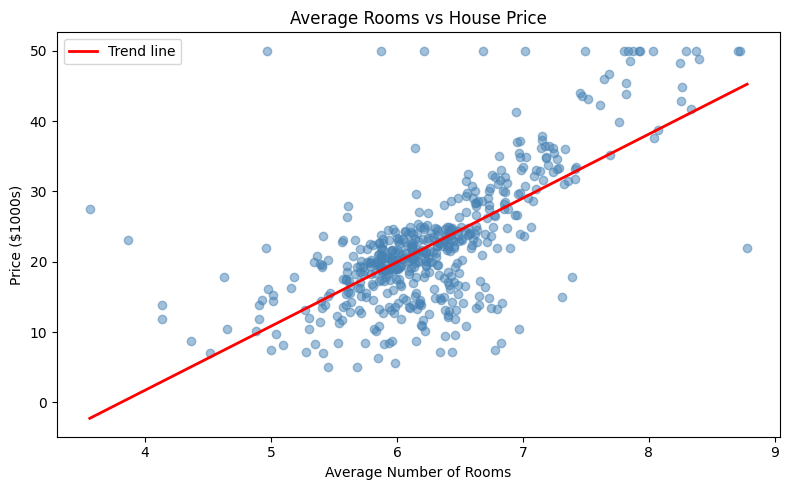

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['avg_rooms'], df['price'], alpha=0.5, color='steelblue')
plt.title('Average Rooms vs House Price')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Price ($1000s)')

# Add a trend line
z = np.polyfit(df['avg_rooms'], df['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['avg_rooms'].min(), df['avg_rooms'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

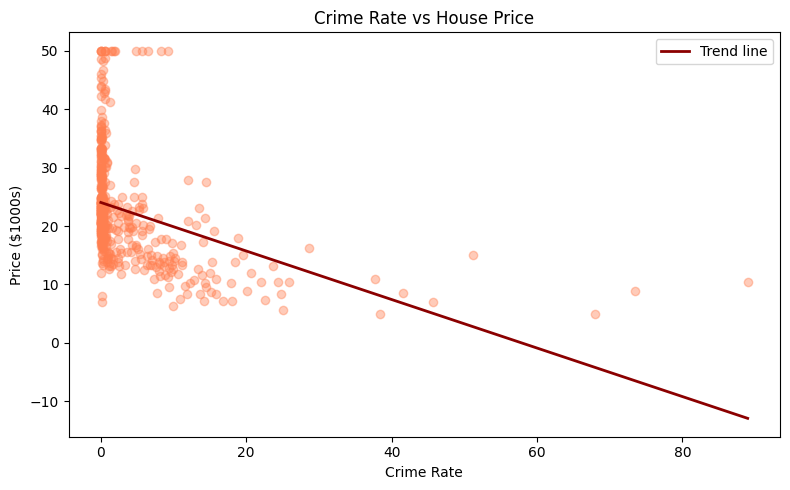

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df['crime_rate'], df['price'], alpha=0.4, color='coral')
plt.title('Crime Rate vs House Price')
plt.xlabel('Crime Rate')
plt.ylabel('Price ($1000s)')

# Trend line
z = np.polyfit(df['crime_rate'], df['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['crime_rate'].min(), df['crime_rate'].max(), 100)
plt.plot(x_line, p(x_line), color='darkred', linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

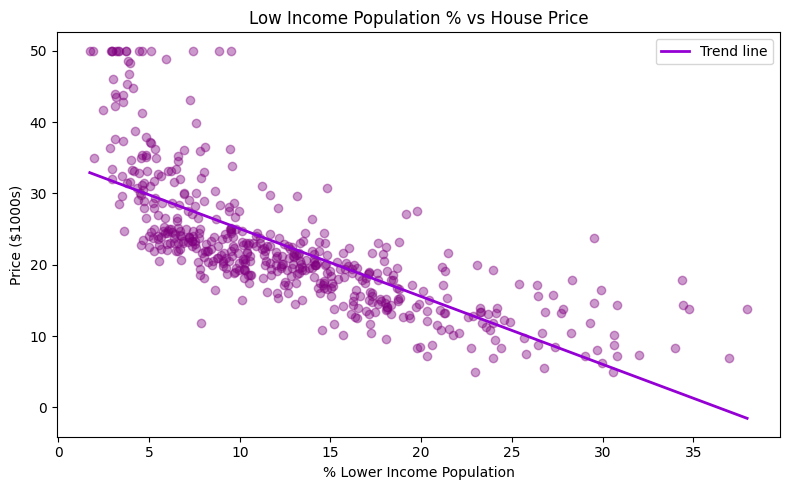

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['low_income_pct'], df['price'], alpha=0.4, color='purple')
plt.title('Low Income Population % vs House Price')
plt.xlabel('% Lower Income Population')
plt.ylabel('Price ($1000s)')

z = np.polyfit(df['low_income_pct'], df['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['low_income_pct'].min(), df['low_income_pct'].max(), 100)
plt.plot(x_line, p(x_line), color='darkviolet', linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_1585/2076046657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='near_river', data=df, y='price', palette='Set2')


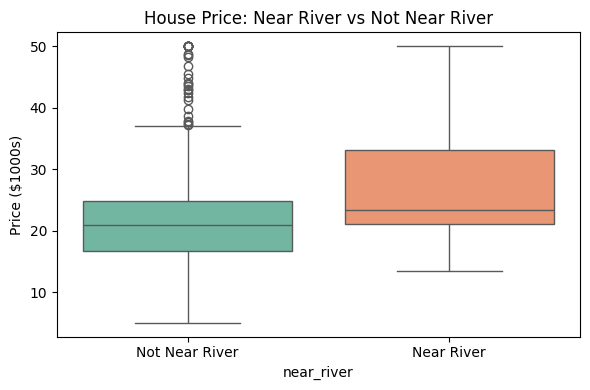

Average price near river    : $28.4k
Average price NOT near river: $22.1k
River premium               : $6.3k more!


In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='near_river', data=df, y='price', palette='Set2')
plt.title('House Price: Near River vs Not Near River')
plt.xticks([0, 1], ['Not Near River', 'Near River'])
plt.ylabel('Price ($1000s)')
plt.tight_layout()
plt.show()

river_yes = df[df['near_river'] == 1]['price'].mean()
river_no  = df[df['near_river'] == 0]['price'].mean()
print(f"Average price near river    : ${river_yes:.1f}k")
print(f"Average price NOT near river: ${river_no:.1f}k")
print(f"River premium               : ${river_yes - river_no:.1f}k more!")

In [16]:
df_clean = df.copy()
print("Copy created! Shape:", df_clean.shape)

Copy created! Shape: (506, 14)


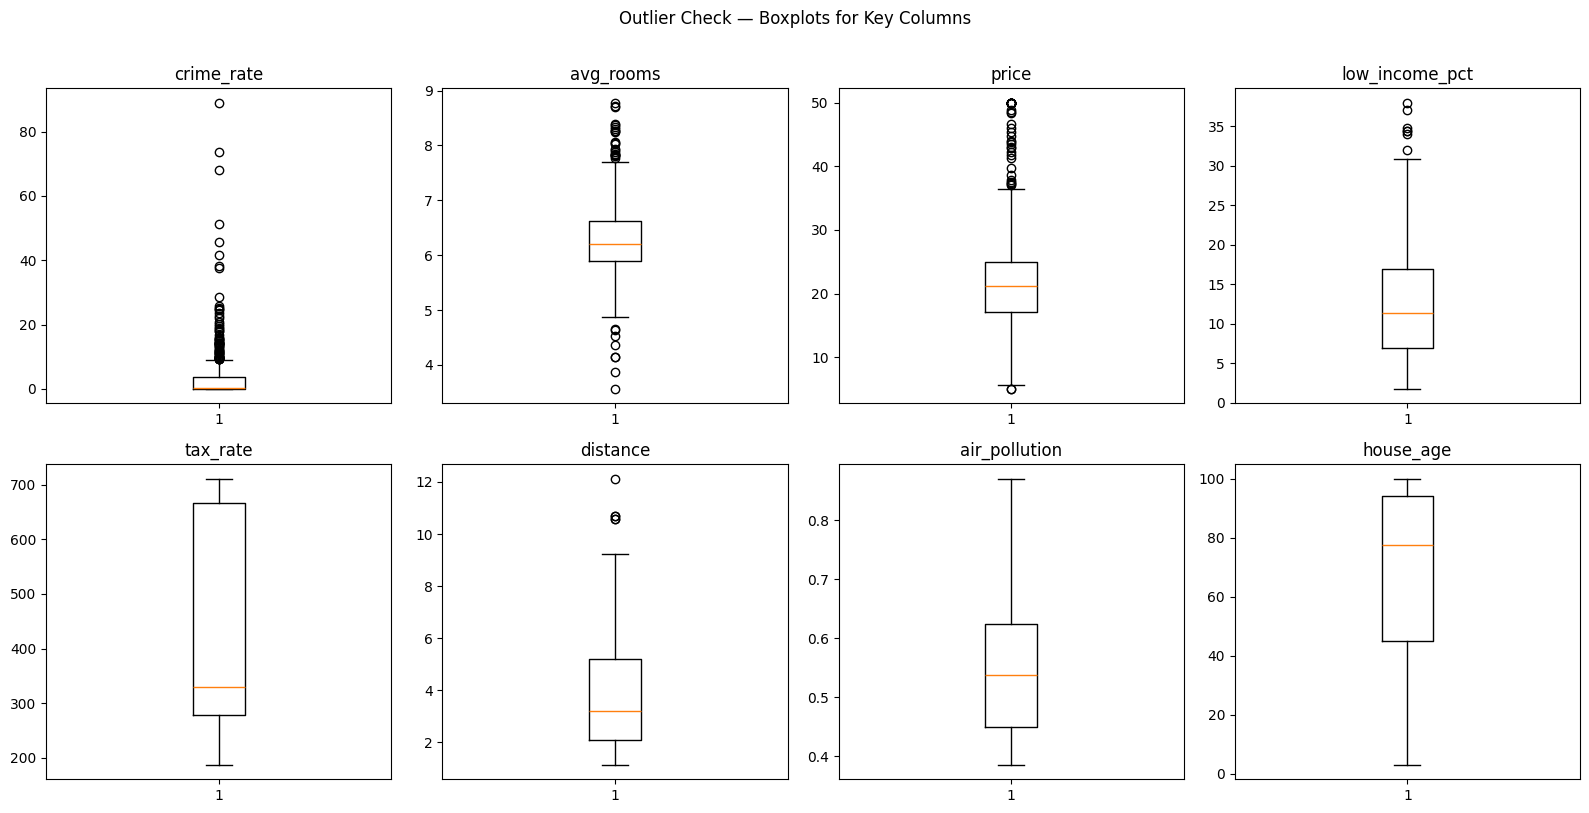

In [17]:
# Check which columns have extreme outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

cols_to_check = ['crime_rate', 'avg_rooms', 'price',
                 'low_income_pct', 'tax_rate', 'distance',
                 'air_pollution', 'house_age']

for i, col in enumerate(cols_to_check):
    axes[i].boxplot(df_clean[col])
    axes[i].set_title(col)

plt.suptitle('Outlier Check — Boxplots for Key Columns', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# You noticed many houses capped at exactly $50k in the charts
# These are likely data entry limits, not real prices — remove them
before = len(df_clean)
df_clean = df_clean[df_clean['price'] < 50.0]
after = len(df_clean)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Removed     : {before - after} capped outlier rows")

Rows before : 506
Rows after  : 490
Removed     : 16 capped outlier rows


In [19]:
# crime_rate goes up to 88 — extreme outliers pull the model wrong
# Remove the top 1% extreme crime values
crime_threshold = df_clean['crime_rate'].quantile(0.99)
before = len(df_clean)
df_clean = df_clean[df_clean['crime_rate'] <= crime_threshold]
after = len(df_clean)

print(f"Crime rate threshold (99th percentile): {crime_threshold:.2f}")
print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Removed     : {before - after} extreme crime outliers")

Crime rate threshold (99th percentile): 41.99
Rows before : 490
Rows after  : 485
Removed     : 5 extreme crime outliers


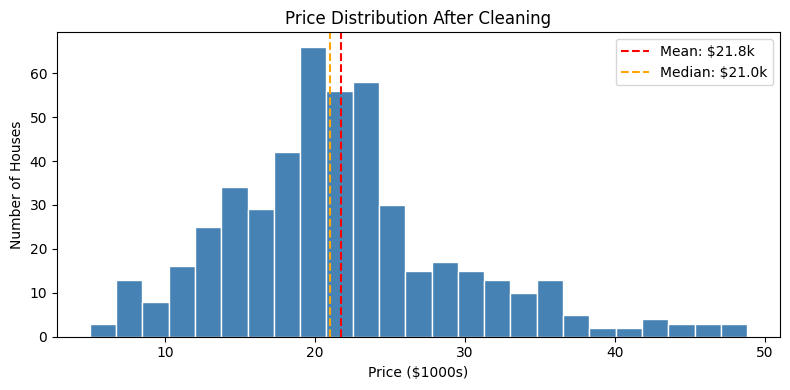


Clean dataset shape: (485, 14)
Price range: $5.0k — $48.8k


In [23]:
plt.figure(figsize=(8, 4))
plt.hist(df_clean['price'], bins=25, color='steelblue', edgecolor='white')
plt.axvline(df_clean['price'].mean(),   color='red',    linestyle='--',
            label=f"Mean: ${df_clean['price'].mean():.1f}k")
plt.axvline(df_clean['price'].median(), color='orange', linestyle='--',
            label=f"Median: ${df_clean['price'].median():.1f}k")
plt.title('Price Distribution After Cleaning')
plt.xlabel('Price ($1000s)')
plt.ylabel('Number of Houses')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nClean dataset shape: {df_clean.shape}")
print(f"Price range: ${df_clean['price'].min()}k — ${df_clean['price'].max()}k")

In [22]:
# near_river is already 0/1 so no encoding needed!
# Let's just confirm all columns are numeric
print("=== DATA TYPES ===")
print(df_clean.dtypes)

print(f"\nAll numeric? {all(df_clean.dtypes != 'object')}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"\nFinal clean shape: {df_clean.shape}")

=== DATA TYPES ===
crime_rate         float64
residential_pct    float64
industry_pct       float64
near_river           int64
air_pollution      float64
avg_rooms          float64
house_age          float64
distance           float64
highway_access       int64
tax_rate             int64
school_ratio       float64
diversity_index    float64
low_income_pct     float64
price              float64
dtype: object

All numeric? True
Missing values: 0

Final clean shape: (485, 14)


In [28]:
# Create 4 new meaningful features

# 1. Rooms per unit of low income % (luxury score)
df_clean['luxury_score'] = df_clean['avg_rooms'] / (df_clean['low_income_pct'] + 1)

# 2. Crime per distance (safety-accessibility ratio)
df_clean['crime_distance_ratio'] = df_clean['crime_rate'] / (df_clean['distance'] + 1)

# 3. Is house old? (above median age = 1, else 0)
median_age = df_clean['house_age'].median()
df_clean['is_old'] = (df_clean['house_age'] > median_age).astype(int)

# 4. Tax burden category (low/mid/high)
df_clean['tax_category'] = pd.qcut(
    df_clean['tax_rate'],
    q=3,
    labels=[0, 1, 2]   # 0=low, 1=mid, 2=high
).astype(int)

print("4 new features created!")
print(f"New shape: {df_clean.shape}")
print(f"\nNew columns: {['luxury_score', 'crime_distance_ratio', 'is_old', 'tax_category']}")
df_clean[['avg_rooms', 'low_income_pct', 'luxury_score',
          'crime_rate', 'distance', 'crime_distance_ratio',
          'house_age', 'is_old', 'tax_rate', 'tax_category']].head()

4 new features created!
New shape: (485, 18)

New columns: ['luxury_score', 'crime_distance_ratio', 'is_old', 'tax_category']


,avg_rooms,low_income_pct,luxury_score,crime_rate,distance,crime_distance_ratio,house_age,is_old,tax_rate,tax_category
0,6.575,4.98,1.099498,0.00632,4.0900,0.001242,65.2,0,296,0
1,6.421,9.14,0.633235,0.02731,4.9671,0.004577,78.9,1,242,0
2,7.185,4.03,1.428429,0.02729,4.9671,0.004573,61.1,0,242,0
3,6.998,2.94,1.776142,0.03237,6.0622,0.004584,45.8,0,222,0
4,7.147,5.33,1.129068,0.06905,6.0622,0.009777,54.2,0,222,0


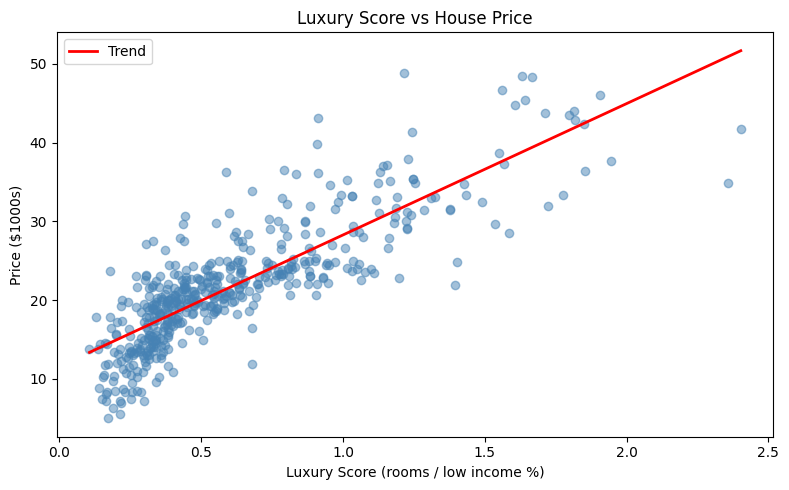

Luxury Score correlation with price: 0.831
Original avg_rooms correlation     : 0.690

Higher correlation = better feature!


In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['luxury_score'], df_clean['price'],
            alpha=0.5, color='steelblue')
plt.title('Luxury Score vs House Price')
plt.xlabel('Luxury Score (rooms / low income %)')
plt.ylabel('Price ($1000s)')

z = np.polyfit(df_clean['luxury_score'], df_clean['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['luxury_score'].min(),
                     df_clean['luxury_score'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

corr = df_clean['luxury_score'].corr(df_clean['price'])
print(f"Luxury Score correlation with price: {corr:.3f}")
print(f"Original avg_rooms correlation     : {df_clean['avg_rooms'].corr(df_clean['price']):.3f}")
print(f"\nHigher correlation = better feature!")

In [30]:
print("=== FINAL DATASET WITH NEW FEATURES ===")
print(f"Shape: {df_clean.shape}")
print(f"\nAll columns ({len(df_clean.columns)}):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

=== FINAL DATASET WITH NEW FEATURES ===
Shape: (485, 18)

All columns (18):
   1. crime_rate
   2. residential_pct
   3. industry_pct
   4. near_river
   5. air_pollution
   6. avg_rooms
   7. house_age
   8. distance
   9. highway_access
  10. tax_rate
  11. school_ratio
  12. diversity_index
  13. low_income_pct
  14. price
  15. luxury_score
  16. crime_distance_ratio
  17. is_old
  18. tax_category

Missing values: 0


,crime_rate,residential_pct,industry_pct,near_river,air_pollution,avg_rooms,house_age,distance,highway_access,tax_rate,school_ratio,diversity_index,low_income_pct,price,luxury_score,crime_distance_ratio,is_old,tax_category
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,1.099498,0.001242,0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.633235,0.004577,1,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1.428429,0.004573,0,0
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1.776142,0.004584,0,0
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1.129068,0.009777,0,0


In [40]:
# X = all features except price
# y = price (what we want to predict)
X = df_clean.drop(columns=['price'])
y = df_clean['price']

print("Features and Target created!")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))

Features and Target created!
X shape: (485, 17)
y shape: (485,)

Feature columns (17):
['crime_rate', 'residential_pct', 'industry_pct', 'near_river', 'air_pollution', 'avg_rooms', 'house_age', 'distance', 'highway_access', 'tax_rate', 'school_ratio', 'diversity_index', 'low_income_pct', 'luxury_score', 'crime_distance_ratio', 'is_old', 'tax_category']


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Train/Test split done!
Training samples : 388
Testing samples  : 97


In [33]:
# Linear Regression — fits a straight line through the data
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred   = lr_model.predict(X_test)
lr_rmse   = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2     = r2_score(y_test, lr_pred)

print("=== LINEAR REGRESSION ===")
print(f"RMSE : ${lr_rmse:.2f}k  (average prediction error)")
print(f"R²   : {lr_r2:.3f}    (1.0 = perfect, 0 = terrible)")

=== LINEAR REGRESSION ===
RMSE : $3.10k  (average prediction error)
R²   : 0.827    (1.0 = perfect, 0 = terrible)


In [34]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree — learns rules like "if rooms > 6 AND crime < 2, price = $28k"
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred  = dt_model.predict(X_test)
dt_rmse  = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2    = r2_score(y_test, dt_pred)

print("=== DECISION TREE ===")
print(f"RMSE : ${dt_rmse:.2f}k  (average prediction error)")
print(f"R²   : {dt_r2:.3f}    (1.0 = perfect, 0 = terrible)")

=== DECISION TREE ===
RMSE : $3.15k  (average prediction error)
R²   : 0.822    (1.0 = perfect, 0 = terrible)


In [35]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest — combines 100 decision trees for better accuracy
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_rmse  = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2    = r2_score(y_test, rf_pred)

print("=== RANDOM FOREST ===")
print(f"RMSE : ${rf_rmse:.2f}k  (average prediction error)")
print(f"R²   : {rf_r2:.3f}    (1.0 = perfect, 0 = terrible)")

=== RANDOM FOREST ===
RMSE : $2.71k  (average prediction error)
R²   : 0.868    (1.0 = perfect, 0 = terrible)


In [36]:
print("=" * 48)
print("          MODEL COMPARISON REPORT")
print("=" * 48)
print(f"{'Model':<22} {'RMSE':>8} {'R² Score':>10}")
print("-" * 48)
print(f"{'Linear Regression':<22} ${lr_rmse:>6.2f}k {lr_r2:>10.3f}")
print(f"{'Decision Tree':<22} ${dt_rmse:>6.2f}k {dt_r2:>10.3f}")
print(f"{'Random Forest':<22} ${rf_rmse:>6.2f}k {rf_r2:>10.3f}")
print("=" * 48)

# Pick best model
models = {'Linear Regression': (lr_rmse, lr_pred),
          'Decision Tree':     (dt_rmse, dt_pred),
          'Random Forest':     (rf_rmse, rf_pred)}
best_name = min(models, key=lambda k: models[k][0])
best_pred = models[best_name][1]
best_rmse = models[best_name][0]

print(f"\n🏆 Best Model: {best_name} (RMSE: ${best_rmse:.2f}k)")

          MODEL COMPARISON REPORT
Model                      RMSE   R² Score
------------------------------------------------
Linear Regression      $  3.10k      0.827
Decision Tree          $  3.15k      0.822
Random Forest          $  2.71k      0.868

🏆 Best Model: Random Forest (RMSE: $2.71k)


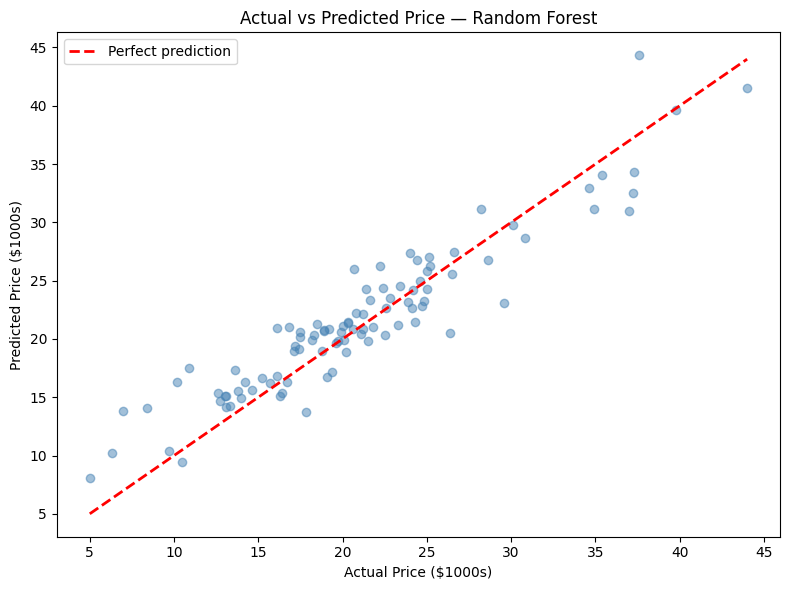

💡 Dots close to the red line = accurate predictions!


In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, linestyle='--', label='Perfect prediction')
plt.title(f'Actual vs Predicted Price — {best_name}')
plt.xlabel('Actual Price ($1000s)')
plt.ylabel('Predicted Price ($1000s)')
plt.legend()
plt.tight_layout()
plt.show()

print("💡 Dots close to the red line = accurate predictions!")

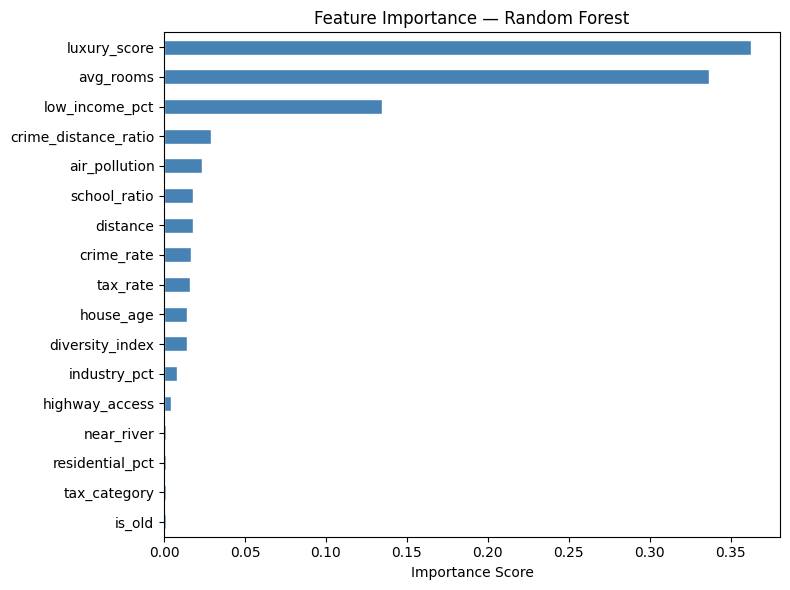


Top 3 most important features:
luxury_score      0.362405
avg_rooms         0.336460
low_income_pct    0.134424
dtype: float64


In [38]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
print(importance.sort_values(ascending=False).head(3))

In [39]:
# Predict price for a specific house
new_house = pd.DataFrame({
    'crime_rate'          : [0.05],
    'residential_pct'     : [20.0],
    'industry_pct'        : [5.0],
    'near_river'          : [1],      # near river = yes
    'air_pollution'       : [0.45],
    'avg_rooms'           : [7.0],    # 7 rooms
    'house_age'           : [20.0],   # fairly new
    'distance'            : [4.0],
    'highway_access'      : [3],
    'tax_rate'            : [300],
    'school_ratio'        : [16.0],
    'diversity_index'     : [390.0],
    'low_income_pct'      : [5.0],    # wealthy area
    'luxury_score'        : [7.0 / (5.0 + 1)],
    'crime_distance_ratio': [0.05 / (4.0 + 1)],
    'is_old'              : [0],
    'tax_category'        : [0]
})

predicted_price = rf_model.predict(new_house)[0]
print("🏠 House: 7 rooms, near river, low crime, wealthy area, new build")
print(f"🤖 Predicted Price: ${predicted_price:.1f}k")
print(f"💰 That's approximately ₹{predicted_price * 83:.0f},000!")

🏠 House: 7 rooms, near river, low crime, wealthy area, new build
🤖 Predicted Price: $31.4k
💰 That's approximately ₹2604,000!
